<h1 style="text-align: center; font-size: 40px; color: gray; font-weight: 700; margin-bottom: 5px;">
    CAPSTONE PROJECT 3
</h1>
<h2 style="text-align: center; font-weight: 500; margin-top: 0;">
    Use Case : Shopee
</h2>

# **Outline**

- [**Section 0.** Import Library](#import-library)
- [**Section 1.** Business Understanding](#business-understanding)
- [**Section 2.** Data Understanding](#data-understanding)
- [**Section 3.** Data Cleaning](#data-cleaning)
- [**Section 4.** Feature Generation](#feature-generation)
- [**Section 5.** Data Anlysis](#data-analysis)
- [**Section 6.** Kesimpulan dan Rekomendasi](#kesimpulan-dan-rekomendasi)


# **IMPORT LIBRARY**



In [2]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc
import statsmodels as st
import matplotlib.ticker as mtick
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

# **BUSINESS UNDERSTANDING**

## **1. BACKGROUND**

Shopee telah berhasil merajai pasar e-commerce di Asia Tenggara melalui strategi pemasaran
yang agresif, khususnya kampanye tanggal kembar (11.11, 12.12) dan fitur gamification seperti
Shopee Tanam atau Shopee Candy. Ekosistem ini dirancang secara khusus untuk
meningkatkan Daily Active Users (DAU) dan menjaga pengguna agar menghabiskan waktu
lebih lama di dalam aplikasi. Sebagai reward, pengguna diberikan Shopee Coins dan berbagai
macam voucher (Gratis Ongkir, Cashback) yang bisa ditumpuk (stacking) saat checkout.

Daya tarik utama lainnya adalah program Flash Sale, di mana barang-barang bernilai tinggi
(seperti iPhone atau TV) dijual dengan harga ekstrem, misalnya Rp 1. Program ini sangat
sukses menciptakan hype dan mendatangkan traffic masif dalam waktu singkat. Namun, traffic
yang tinggi ini ternyata tidak berbanding lurus dengan kualitas konversi. Tim Anti-Fraud mulai
mendeteksi bahwa barang-barang Flash Sale seringkali habis dalam waktu kurang dari 1 detik.

Usut punya usut, sistem Shopee dibanjiri oleh aktivitas bot (skrip otomatis) dan scalper yang
secara sistematis memborong barang Flash Sale untuk dijual kembali di platform lain. Hal ini
memicu gelombang protes dari user asli di media sosial yang merasa ditipu karena tidak pernah
kebagian barang. Selain merusak citra brand, aktivitas ini membuat subsidi diskon miliaran
rupiah jatuh ke tangan sindikat penipu, bukan ke target konsumen yang sebenarnya.

Masalah semakin runyam di sisi validasi Voucher dan Shopee Coins. Tim Data Engineer
melaporkan adanya kejanggalan pada sistem checkout. Ditemukan banyak transaksi yang
berhasil menggunakan voucher diskon besar, padahal total belanjanya tidak memenuhi syarat
Minimum Spend (Konteks Bisnis Error). Selain itu, pencatatan perangkat pengguna (Device
OS) di database sangat berantakan, membuat tim Security kesulitan melacak Device ID mana
saja yang di-kloning untuk membuat ribuan akun bodong.

Oleh karena itu, analisis mendalam terhadap log transaksi Flash Sale, penggunaan voucher,
dan pergerakan Shopee Coins ini sangat mendesak untuk dieksekusi. Tanpa adanya
pembersihan data dan identifikasi pola bot secara komprehensif, Shopee akan terus
"membakar uang" untuk mensubsidi sindikat fraudster, sementara pengguna asli (real users)
justru perlahan-lahan churn karena kehilangan kepercayaan terhadap platform. Analisis ini
adalah kunci untuk menyelamatkan budget promosi perusahaan.

## **2. PROBLEM STATEMENT**

**Masalah Utama:** Kerugian finansial dan menurunnya kepercayaan pengguna asli akibat
aktivitas Bot/Scalper pada Flash Sale serta penyalahgunaan (abuse) sistem Voucher dan
Shopee Coins.

**Masalah Turunan:**
1. Bagaimana pola durasi checkout (dari masuk keranjang hingga bayar) yang
mengindikasikan transaksi tersebut dilakukan oleh bot/script?

2. Berapa estimasi kerugian dari kebocoran sistem di mana Voucher berhasil dipakai
padahal transaksi tidak memenuhi syarat Minimum Spend?
3. Device ID mana saja yang terafiliasi dengan ratusan akun berbeda (indikasi farm
account)?
4. Seberapa berantakan pencatatan Device OS di sistem, dan bagaimana cara
menstandarisasinya untuk kebutuhan analisis perangkat fraud?
5. Berapa banyak anomali/outliers di mana user me-redeem (menukarkan) Shopee Coins
melebihi batas saldo wajar atau bahkan bernilai negatif?
6. Apakah ada korelasi antara metode pembayaran tertentu (misal: Transfer Bank Manual)
dengan tingkat keberhasilan transaksi bot di Flash Sale?

## **3. GOALS**

Tujuan utama dari analisis ini adalah untuk menyelamatkan anggaran promosi dan meningkatkan integritas platform:

**Bot Mitigation:** Membangun aturan atau model otomatis untuk memblokir transaksi dengan durasi checkout di bawah standar manusia.

**System Patching:** Mengidentifikasi celah (bug) pada sistem validasi transaksi agar penggunaan voucher tepat sasaran sesuai syarat belanja.

**Data Cleansing:** Menghasilkan tabel referensi Device OS yang bersih untuk mempermudah operasional tim Anti-Fraud.

**Budget Optimization:** Memastikan dana pemasaran (Koin & Voucher) hanya dinikmati oleh pengguna asli untuk menyehatkan metrik retensi dan Customer Loyalty Value (CLV).

## **4. ANALYTICAL APPROACH**

Analisis ini bertujuan untuk mengidentifikasi aktivitas bot pada Flash Sale, penyalahgunaan voucher dan Shopee Coins, serta pola fraud berbasis device dan masalah kualitas data. Pendekatan yang digunakan meliputi rule-based fraud detection untuk mendeteksi perilaku tidak wajar (seperti checkout terlalu cepat dan misuse voucher), exploratory data analysis (EDA) untuk menemukan pola dan anomali, serta data cleaning untuk menstandarisasi data seperti device OS.

Analisis dilakukan melalui proses data preparation, feature engineering (misalnya pembuatan flag is_bot, voucher_bug, dan coins_anomaly), serta agregasi dan visualisasi data. Hasil yang diharapkan adalah insight terkait tingkat fraud dan estimasi kerugian, serta rekomendasi bisnis untuk meningkatkan validasi sistem dan efektivitas penggunaan budget promosi. Pendekatan ini juga dapat dikembangkan lebih lanjut menjadi model machine learning untuk fraud detection secara real-time.

# **DATA UNDERSTANDING**

## **1. DESKRIPSI DATASET**

- Sumber dataset: Data simulasi transaksi e-commerce Shopee (internal  dataset untuk analisis fraud).

- Jumlah baris: 300.000 (pada tabel orders).
- Jumlah tabel: 3 tabel utama (users, vouchers, orders).
- Tipe problem: Fraud detection & anomaly analysis (rule-based analysis).

Note:
- Dataset terdiri dari data pengguna, transaksi, dan voucher yang saling terhubung.
- Analisis difokuskan untuk mengidentifikasi aktivitas bot, abuse sistem, serta pola fraud berbasis device.

### Struktur Dataset

1. **Users Dataset (shopee_users)**

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| **`user_id`** | Kategorikal | ID unik untuk setiap pengguna |
| **`device_id`** | Kategorikal | ID perangkat yang digunakan oleh pengguna |
| **`device_os`** | Kategorikal | Sistem operasi perangkat (Android, iOS, dll.) |
| **`coins_balance`** | Numerik |Saldo Shopee Coins yang dimiliki pengguna |

2. **Vouchers Dataset (shopee_vouchers)**

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| **`voucher_code`** | Kategorikal | Kode unik voucher |
| **`voucher_type`** | Kategorikal | Jenis voucher (Gratis Ongkir, Cashback, Diskon) |
| **`min_spend`** | Numerik | Minimum transaksi agar voucher dapat digunakan |
| **`discount_amount`** | Numerik | Nilai diskon yang diberikan oleh voucher |

3. **Orders Dataset (shopee_orders)**

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| **`order_id`** | Kategorikal | ID unik untuk setiap transaksi |
| **`user_id`** | Kategorikal | ID unik untuk setiap pengguna |
| **`order_time`** | Kategorikal | Waktu transaksi dilakukan |
|**`is_flash_sale`** | Binary | Status apakah transaksi terjadi saat Flash Sale (YES/NO) |
| **`checkout_duration_sec`** | Numerik | Durasi checkout dari keranjang ke pembayaran (dalam detik) |
| **`total_amount`** | Numerik | Total nilai transaksi sebelum diskon |
| **`voucher_code`** | Kategorikal | Kode voucher yang digunakan (jika ada) |
| **`coins_redeemed`** | Numerik | Jumlah Shopee Coins yang digunakan dalam transaksi |



## **2. DATASET PREVIEW**

In [3]:
# Load Dataset

order = pd.read_csv("shopee_orders.csv")
user = pd.read_csv("shopee_users.csv")
voucher = pd.read_csv("shopee_vouchers.csv")


In [4]:
# Menggabungkan Dataset

df = pd.merge(order, user, on= 'user_id', how= 'left')
df_merge = pd.merge(df, voucher, on= 'voucher_code', how='left')

df_merge.sample(5)

,order_id,user_id,order_time,is_flash_sale,checkout_duration_sec,total_amount,voucher_code,coins_redeemed,device_id,device_os,coins_balance,voucher_type,min_spend,discount_amount
41911,ORD-SHP-0041912,SHP-005986,2023-11-09 23:06:00,False,78.14,115822,NaN,0,DEV-02569,mac,49981,NaN,NaN,NaN
48855,ORD-SHP-0048856,SHP-011809,2023-11-14 11:03:00,False,206.54,1705552,NaN,1000,DEV-00678,mac,37578,NaN,NaN,NaN
63225,ORD-SHP-0063226,SHP-017732,2023-11-30 04:21:00,False,178.96,1503246,VCH070SALE,5000,DEV-00072,Android,17593,Diskon 50%,120000.0,12742.0
80794,ORD-SHP-0080795,SHP-011955,2023-11-22 05:48:00,True,14.46,1102293,NaN,0,DEV-06977,Android,43599,NaN,NaN,NaN
12670,ORD-SHP-0012671,SHP-014920,2023-11-10 02:28:00,False,51.23,739005,VCH029SALE,0,DEV-02190,Android,27741,Diskon 50%,300000.0,19483.0


In [5]:
# Dataset General Information

df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               300000 non-null  object 
 1   user_id                300000 non-null  object 
 2   order_time             300000 non-null  object 
 3   is_flash_sale          300000 non-null  bool   
 4   checkout_duration_sec  300000 non-null  float64
 5   total_amount           300000 non-null  int64  
 6   voucher_code           150000 non-null  object 
 7   coins_redeemed         300000 non-null  int64  
 8   device_id              290947 non-null  object 
 9   device_os              300000 non-null  object 
 10  coins_balance          300000 non-null  int64  
 11  voucher_type           150000 non-null  object 
 12  min_spend              150000 non-null  float64
 13  discount_amount        150000 non-null  float64
dtypes: bool(1), float64(3), int64(3), ob

Missing values pada voucher_code, voucher_type, min_spend, dan discount_amount mengindikasikan bahwa tidak semua transaksi menggunakan voucher. Selain itu, terdapat juga sedikit missing value pada kolom device_id.

In [6]:
# Statistical Summary

df_merge.describe()

,checkout_duration_sec,total_amount,coins_redeemed,coins_balance,min_spend,discount_amount
count,300000.000000,3.000000e+05,3.000000e+05,300000.000000,150000.00000,150000.000000
mean,149.843933,9.857695e+05,2.449420e+06,24922.189890,111924.20000,26983.378687
std,86.622502,5.848057e+05,3.490231e+07,14458.978728,115036.84487,13271.178661
min,0.100000,1.000000e+03,-9.999000e+03,2.000000,0.00000,6615.000000
25%,74.620000,4.743948e+05,0.000000e+00,12292.000000,30000.00000,14376.000000
50%,149.860000,9.860440e+05,0.000000e+00,24938.000000,50000.00000,27150.000000
75%,224.960000,1.493640e+06,1.000000e+03,37529.000000,300000.00000,38158.000000
max,300.000000,1.999988e+06,5.000000e+08,49996.000000,300000.00000,49948.000000


Rata-rata durasi checkout berada di sekitar 149 detik, dengan nilai minimum sangat kecil (0.1 detik) yang mengindikasikan kemungkinan aktivitas bot atau otomatisasi.

Pada fitur coins_redeemed, ditemukan nilai minimum negatif  dan nilai maksimal yang sangat besar, yang mengindikasikan adanya anomali atau error dalam sistem penggunaan koin.

# **DATA CLEANING**

## **1. DATA TYPE**

In [7]:
# Konversi Tipe Data Pada Kolom `order_time`

df_merge['order_time'] = pd.to_datetime(df_merge['order_time'])

In [8]:
df_merge['min_spend'] = df_merge['min_spend'].astype('Int64')

In [9]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               300000 non-null  object        
 1   user_id                300000 non-null  object        
 2   order_time             300000 non-null  datetime64[ns]
 3   is_flash_sale          300000 non-null  bool          
 4   checkout_duration_sec  300000 non-null  float64       
 5   total_amount           300000 non-null  int64         
 6   voucher_code           150000 non-null  object        
 7   coins_redeemed         300000 non-null  int64         
 8   device_id              290947 non-null  object        
 9   device_os              300000 non-null  object        
 10  coins_balance          300000 non-null  int64         
 11  voucher_type           150000 non-null  object        
 12  min_spend              150000 non-null  Int6

## **2. MISSING VALUE**

In [10]:
# Cek Missing Value

(df_merge.isna().sum()/len(df_merge)*100).sort_values(ascending=False)

,0
discount_amount,50.000000
voucher_code,50.000000
voucher_type,50.000000
min_spend,50.000000
device_id,3.017667
order_id,0.000000
total_amount,0.000000
checkout_duration_sec,0.000000
is_flash_sale,0.000000
order_time,0.000000


In [11]:
df_merge.isnull().sum().sort_values(ascending=False)

,0
discount_amount,150000
voucher_code,150000
voucher_type,150000
min_spend,150000
device_id,9053
order_id,0
total_amount,0
checkout_duration_sec,0
is_flash_sale,0
order_time,0


Missing Value pada kolom `discount_amount`,`voucher_code`,`voucher_type`,`min_spend` sebesar 50% atau sebanyak 150000, dan Missing Values pada kolom `device_id` sebesar 3% atau sebanyak 9053 data.


In [12]:
# Handle Missing Value

fill_values = {
    'discount_amount': 0,
    'voucher_code': 'No Voucher',
    'voucher_type': 'No Promo',
    'min_spend': 0
}

df_merge.fillna(value=fill_values, inplace=True)

In [13]:
df_merge['device_id'] = df_merge['device_id'].fillna('Unknown')

In [14]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               300000 non-null  object        
 1   user_id                300000 non-null  object        
 2   order_time             300000 non-null  datetime64[ns]
 3   is_flash_sale          300000 non-null  bool          
 4   checkout_duration_sec  300000 non-null  float64       
 5   total_amount           300000 non-null  int64         
 6   voucher_code           300000 non-null  object        
 7   coins_redeemed         300000 non-null  int64         
 8   device_id              300000 non-null  object        
 9   device_os              300000 non-null  object        
 10  coins_balance          300000 non-null  int64         
 11  voucher_type           300000 non-null  object        
 12  min_spend              300000 non-null  Int6

Data dengan Missing Value diisi dengan menambahkan value berupa label 'No Voucher', 'No Promo', 0, dan Unknown. Karena jika dihapus maka hasil analisa bisa akan menjadi bias.

## **3. DATA DUPLICATE**

In [15]:
# Cek Duplikat Data
duplicate_count = df_merge.duplicated().sum()
duplicate_percent = (duplicate_count / len(df_merge)) * 100
duplicate_rows = df_merge[df_merge.duplicated(keep=False)].sort_values(by=list(df_merge.columns))

print(f"Total Baris Duplikat: {duplicate_count}")
print(f"Persentase dari Total Data: {duplicate_percent:.4f}%")
print("\nSampel Pasangan Data Duplikat:")
display(duplicate_rows)

Total Baris Duplikat: 0
Persentase dari Total Data: 0.0000%

Sampel Pasangan Data Duplikat:


,order_id,user_id,order_time,is_flash_sale,checkout_duration_sec,total_amount,voucher_code,coins_redeemed,device_id,device_os,coins_balance,voucher_type,min_spend,discount_amount


Tidak ditemukan duplikasi data pada dataset.

## **4. OUTLIERS DETECTION**

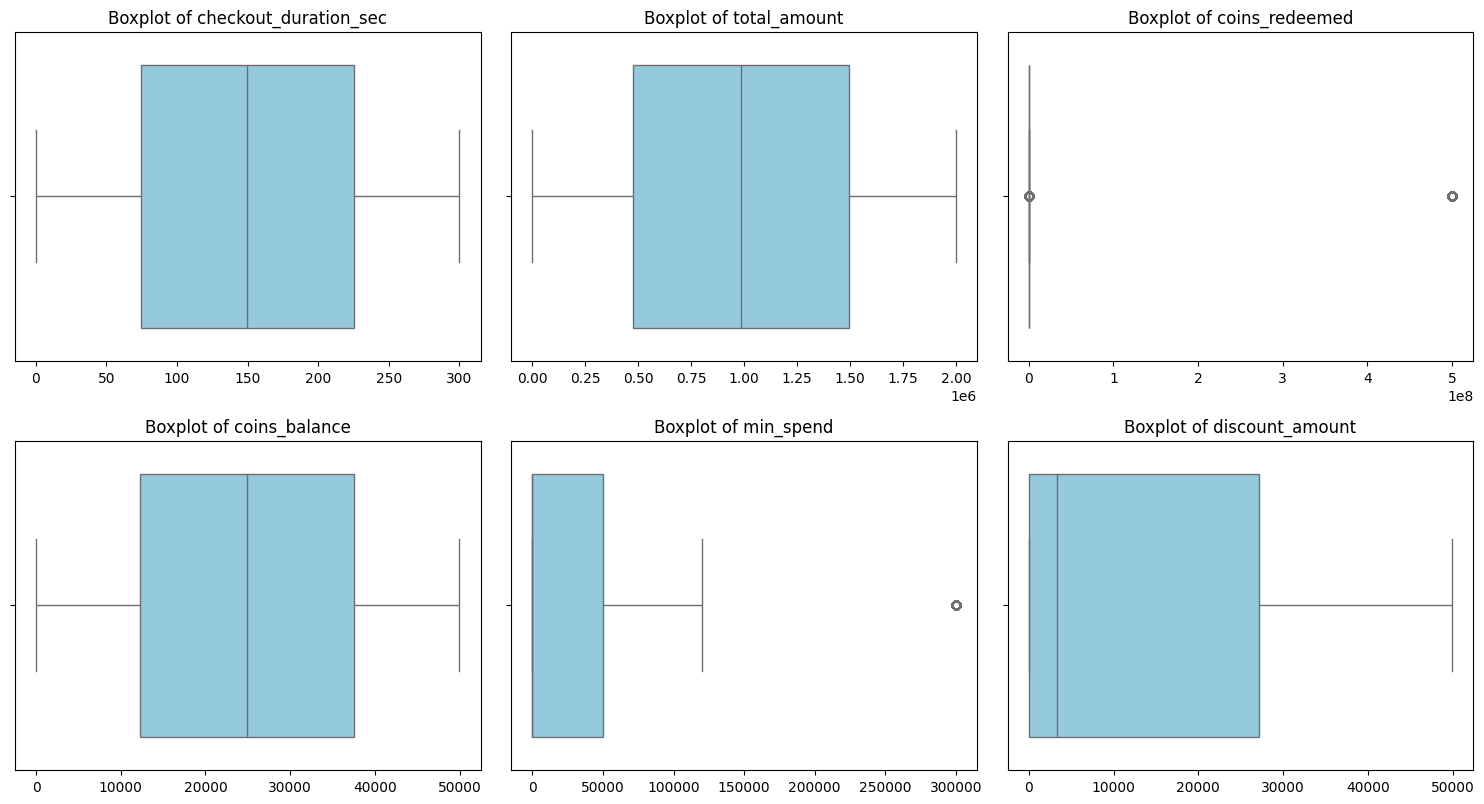

Jumlah Outliers per Kolom (Metode IQR):


,0
checkout_duration_sec,0
total_amount,0
coins_redeemed,47547
coins_balance,0
min_spend,37581
discount_amount,0


In [16]:
# Check Outliers Feature Numbers (Bukan Kategori Yang Di Buat Numbers)
numeric_cols = ['checkout_duration_sec', 'total_amount', 'coins_redeemed', 'coins_balance', 'min_spend', 'discount_amount']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df_merge[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

# Calculate Outlier Counts for Analysis
outlier_report = {}
for col in numeric_cols:
    Q1 = df_merge[col].quantile(0.25)
    Q3 = df_merge[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_merge[(df_merge[col] < lower_bound) | (df_merge[col] > upper_bound)]
    outlier_report[col] = len(outliers)

print("Jumlah Outliers per Kolom (Metode IQR):")
display(pd.Series(outlier_report))

In [17]:
print(f'coins_redeemed : {df_merge['coins_redeemed'].unique()}')
print(f'min_spend : {df_merge['min_spend'].unique()}')

coins_redeemed : [        0      1000      5000 500000000     10000     -9999]
min_spend : <IntegerArray>
[30000, 0, 300000, 120000, 50000]
Length: 5, dtype: Int64


Berdasarkan analisis visual boxplot dan pemahaman konteks bisnis, tidak semua *outlier* merupakan data yang salah/harus dihapus.

**Rencana Penanganan Outliers**

`coins_redeemed` : hapus outliers pada data asli dan dibuatkan dataframe baru khusus untuk data outliers.

`min_spend` : membiarkan *(Keep)* data outliers dari kolom ini.

In [18]:
# Membersihkan data dari Outliers yang ada pada kolom 'coins_redeemed'
df_merge_clean = df_merge[(df_merge['coins_redeemed'] < 500000000) & (df_merge['coins_redeemed'] >= 0)]
df_merge_clean.head()

,order_id,user_id,order_time,is_flash_sale,checkout_duration_sec,total_amount,voucher_code,coins_redeemed,device_id,device_os,coins_balance,voucher_type,min_spend,discount_amount
0,ORD-SHP-0000001,SHP-018452,2023-11-14 22:48:00,False,231.09,23737,VCH023SALE,0,DEV-08453,android,36163,Diskon 50%,30000,18403.0
1,ORD-SHP-0000002,SHP-015226,2023-11-20 07:42:00,False,250.47,382011,No Voucher,0,DEV-05988,android,32309,No Promo,0,0.0
2,ORD-SHP-0000003,SHP-008525,2023-11-06 05:04:00,False,100.75,1440505,No Voucher,1000,DEV-07448,iOS,33827,No Promo,0,0.0
3,ORD-SHP-0000004,SHP-007609,2023-11-27 01:00:00,False,159.73,799403,No Voucher,5000,DEV-06821,IOS,39284,No Promo,0,0.0
4,ORD-SHP-0000005,SHP-007025,2023-11-15 09:38:00,False,143.81,303017,No Voucher,0,DEV-03849,android,11332,No Promo,0,0.0


# **FEATURE GENERATION**

## **MEMBUAT KOLOM `is_bot`**



In [19]:
# Membuat Sebuah Kolom Baru Dari Checkout Duration Sec
anomaly_bot = df_merge_clean['checkout_duration_sec'] < 1

df_merge_clean['is_bot'] = 'No'
df_merge_clean.loc[anomaly_bot, 'is_bot'] = 'Yes'

pd.crosstab(df_merge_clean['is_flash_sale'], df_merge_clean['is_bot'])

is_bot,No,Yes
is_flash_sale,,
False,282225,0
True,11048,3727


Memberikan *(flag)* atau tanda untuk memisahkan transaksi yang mengindikasikan transaksi tersebut dilakukan oleh bot (durasi checkoutnya < 1 detik).

## **MEMBUAT KOLOM `voucher_bug`**

In [20]:
# Membuat Sebuah Kolom Baru
anomaly_voucher = (df_merge_clean['voucher_code'] != 'No Voucher') & (df_merge_clean['total_amount'] < df_merge_clean['min_spend'])
df_merge_clean['voucher_bug'] = 'No'
df_merge_clean.loc[anomaly_voucher, 'voucher_bug'] = 'Yes'

pd.crosstab(df_merge_clean['is_flash_sale'], df_merge_clean['voucher_bug'])

voucher_bug,No,Yes
is_flash_sale,,
False,269335,12890
True,14089,686


Memberikan *(flag)* atau tanda yg memisahkan transaksi bahwa transaksi tersebut mengalami bug pada voucher (total amount < min spend).

## **MENAMBAHKAN KOLOM `net_revenue`**



In [21]:
df_merge_clean['net_revenue'] = df_merge_clean['total_amount'] - df_merge_clean['coins_redeemed'] - df_merge_clean['discount_amount']

## **2. FINAL PREVIEW**

In [22]:
# Tampilan data yang sudah bersih
df_merge_clean.sample(5)

,order_id,user_id,order_time,is_flash_sale,checkout_duration_sec,total_amount,voucher_code,coins_redeemed,device_id,device_os,coins_balance,voucher_type,min_spend,discount_amount,is_bot,voucher_bug,net_revenue
162851,ORD-SHP-0162852,SHP-008979,2023-11-23 10:07:00,False,228.02,887327,VCH075SALE,0,DEV-09210,IOS,5319,Cashback 10%,300000,12540.0,No,No,874787.0
185491,ORD-SHP-0185492,SHP-013978,2023-11-15 03:18:00,False,241.71,1463350,VCH047SALE,5000,DEV-04342,android,25004,Diskon 50%,120000,13525.0,No,No,1444825.0
108937,ORD-SHP-0108938,SHP-019491,2023-11-17 16:56:00,False,64.64,1697085,No Voucher,0,DEV-02920,Android,10382,No Promo,0,0.0,No,No,1697085.0
224570,ORD-SHP-0224571,SHP-006335,2023-11-18 08:39:00,False,299.75,1382758,No Voucher,0,DEV-03741,android,6309,No Promo,0,0.0,No,No,1382758.0
165852,ORD-SHP-0165853,SHP-016148,2023-11-12 10:44:00,False,291.88,857491,No Voucher,0,DEV-07791,Android,22473,No Promo,0,0.0,No,No,857491.0


# **DATA ANALYSIS**

## **1. Seberapa berantakan pencatatan Device OS di sistem, dan bagaimana cara menstandarisasinya untuk kebutuhan analisis perangkat fraud?**

In [23]:
# Mengecek Inkonsistensi Data (Penulisan Kategori)

df_merge_clean['device_os'].value_counts()

,count
device_os,
android,88564
Android,60429
IOS,43956
iOS,29278
WEB,16046
iphone,15314
web browser,14630
ANDROID,14425
mac,14358


In [24]:
# Handle Inkonsistensi Data (Penulisan Kategori)

df_merge_clean['device_os'] = df_merge_clean['device_os'].str.strip().str.lower()

kat = {
    'iphone' : 'ios',
    'mac' : 'web browser',
    'web' : 'web browser'
}
df_merge_clean['device_os'] = df_merge_clean['device_os'].replace(kat)

df_merge_clean['device_os'].value_counts()

,count
device_os,
android,163418
ios,88548
web browser,45034


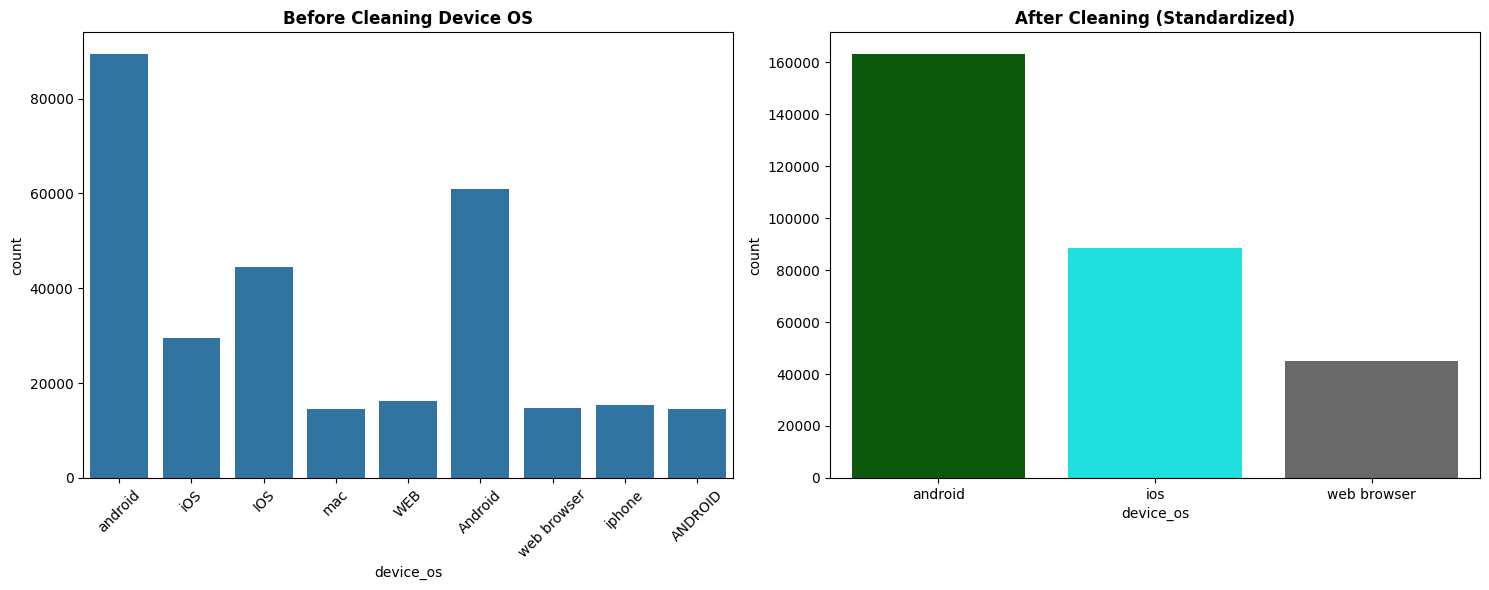

In [25]:
plt.figure(figsize=(15, 6))

# Before Cleaning
plt.subplot(1, 2, 1)
sns.countplot(data=df_merge, x='device_os')
plt.title('Before Cleaning Device OS', fontweight='bold')
plt.xticks(rotation=45)

# After Cleaning
plt.subplot(1, 2, 2)
colors = {'android': 'darkgreen', 'ios': 'cyan', 'web browser': 'dimgray'}
sns.countplot(data=df_merge_clean, x='device_os', palette=colors)
plt.title('After Cleaning (Standardized)', fontweight='bold')

plt.tight_layout()
plt.show()

Berdasarkan analisis `device_os`, ditemukan inkonsistensi yang signifikan dalam pencatatan sistem operasi perangkat. Sebelum pembersihan, terdapat 9 kategori yang berbeda (misalnya, 'android', 'Android' dan sejenisnya). Hal ini menyulitkan analisis karena sistem menganggap 'android' dan 'Android' sebagai kategori terpisah.

Setelah standarisasi, berhasil dirapikan menjadi 3 kategori utama dan konsisten: 'android', 'ios', dan 'web browser'.

**Kesimpulan:** Pencatatan `device_os` awalnya sangat berantakan, namun berhasil distandarisasi untuk memungkinkan analisis yang lebih tepat mengenai pola penggunaan perangkat, yang krusial untuk deteksi *fraud*.

## **2. Berapa banyak anomali/outliers di mana user me-redeem (menukarkan) Shopee Coins melebihi batas saldo wajar atau bahkan bernilai negatif?**

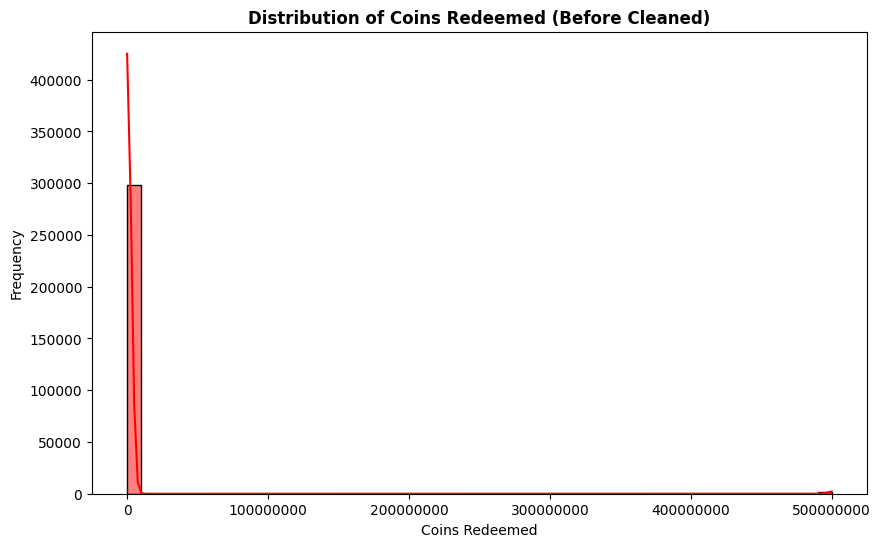

Statistik Deskriptif coins_redeemed:
count    3.000000e+05
mean     2.449420e+06
std      3.490231e+07
min     -9.999000e+03
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+03
max      5.000000e+08
Name: coins_redeemed, dtype: float64


In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(df_merge['coins_redeemed'], bins=50, kde=True, color='red')
plt.title('Distribution of Coins Redeemed (Before Cleaned)', fontweight='bold')
plt.xlabel('Coins Redeemed')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Menampilkan statistik deskriptif untuk kolom tersebut
print("Statistik Deskriptif coins_redeemed:")
print(df_merge['coins_redeemed'].describe())

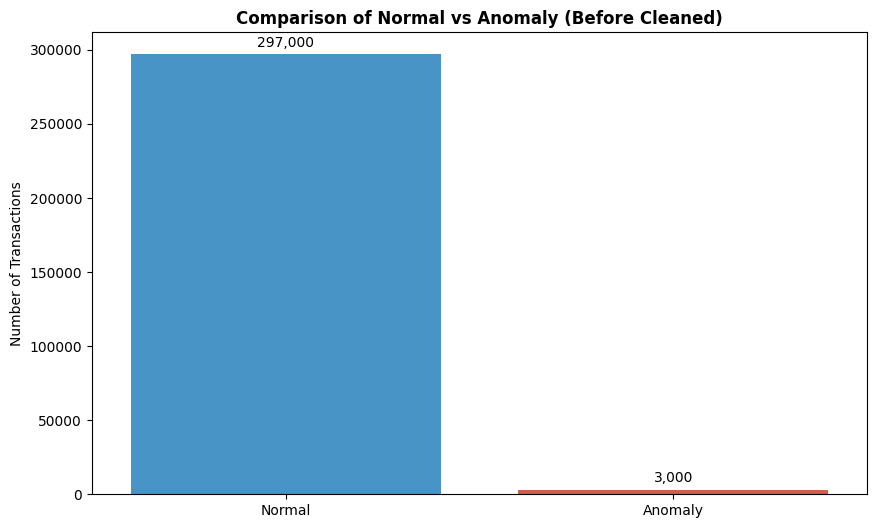

In [46]:
counts = {'Normal': len(df_merge_clean), 'Anomaly': len(df_merge) - len(df_merge_clean)}

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette=['#3498db', '#e74c3c'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height() + 5000), ha='center')

plt.title('Comparison of Normal vs Anomaly (Before Cleaned)', fontweight='bold')
plt.ylabel('Number of Transactions')
plt.show()

In [28]:
# Membuat dataframe baru yang berisi Outliers pada kolom 'coins_redeemed'
df_coin_anomaly = df_merge[(df_merge['coins_redeemed'] == 500000000) | (df_merge['coins_redeemed'] == -9999)]
df_coin_anomaly

,order_id,user_id,order_time,is_flash_sale,checkout_duration_sec,total_amount,voucher_code,coins_redeemed,device_id,device_os,coins_balance,voucher_type,min_spend,discount_amount
5,ORD-SHP-0000006,SHP-016912,2023-11-20 11:22:00,False,48.00,386974,No Voucher,500000000,DEV-01407,android,552,No Promo,0,0.0
120,ORD-SHP-0000121,SHP-018718,2023-11-26 00:59:00,False,140.08,241106,No Voucher,-9999,DEV-07688,iOS,39306,No Promo,0,0.0
144,ORD-SHP-0000145,SHP-012742,2023-11-20 08:05:00,False,288.33,661196,No Voucher,-9999,DEV-02628,Android,9910,No Promo,0,0.0
778,ORD-SHP-0000779,SHP-018120,2023-11-30 23:05:00,False,280.44,178026,VCH061SALE,500000000,DEV-03360,mac,9172,Cashback 10%,300000,42992.0
781,ORD-SHP-0000782,SHP-015129,2023-11-22 13:51:00,False,77.73,1444392,VCH049SALE,-9999,DEV-04420,android,33862,Cashback 10%,50000,46518.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299363,ORD-SHP-0299364,SHP-006237,2023-11-19 00:16:00,False,224.29,681196,No Voucher,500000000,DEV-01846,android,12377,No Promo,0,0.0
299555,ORD-SHP-0299556,SHP-014117,2023-11-14 21:23:00,False,63.05,639121,No Voucher,500000000,DEV-01000,android,13035,No Promo,0,0.0
299819,ORD-SHP-0299820,SHP-006381,2023-11-10 12:37:00,False,288.65,1209462,No Voucher,-9999,DEV-01371,Android,23077,No Promo,0,0.0
299949,ORD-SHP-0299950,SHP-016625,2023-11-16 11:46:00,False,197.06,63486,VCH079SALE,-9999,DEV-00359,mac,21679,Gratis Ongkir,300000,47692.0


### **Data Clean**

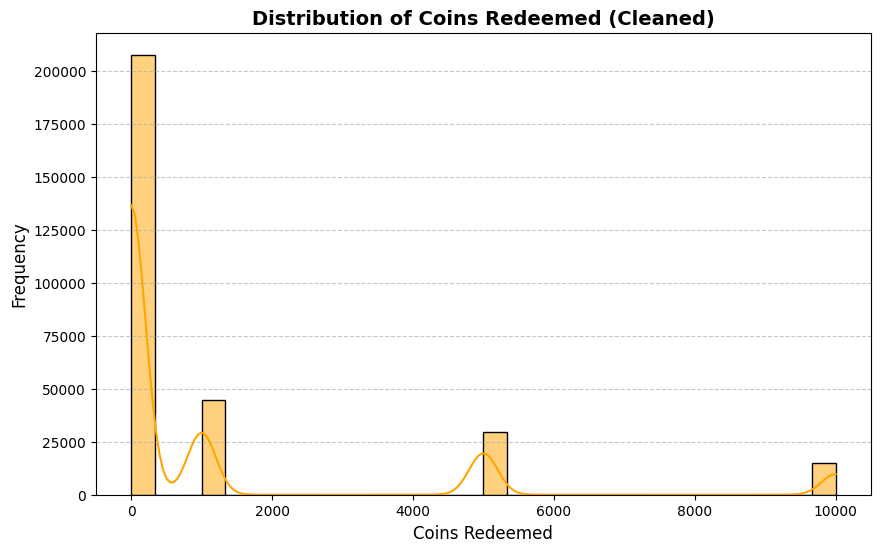

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df_merge_clean['coins_redeemed'], bins=30, kde=True, color='orange', edgecolor='black')
plt.title('Distribution of Coins Redeemed (Cleaned)', fontsize=14, fontweight='bold')
plt.xlabel('Coins Redeemed', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

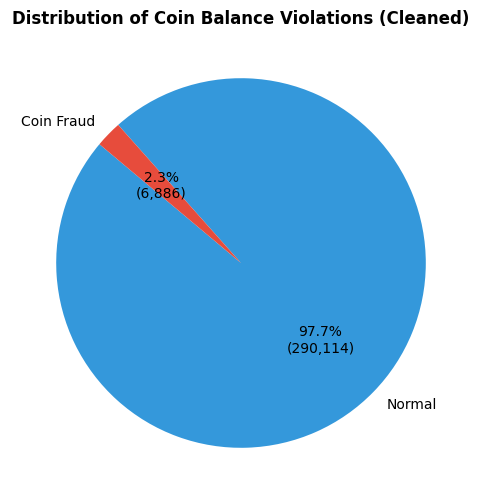

In [30]:
coin_anomalies = df_merge_clean[df_merge_clean['coins_redeemed'] > df_merge_clean['coins_balance']]

fraud_counts = {'Normal': len(df_merge_clean) - len(coin_anomalies), 'Coin Fraud': len(coin_anomalies)}

plt.figure(figsize=(8, 6))
plt.pie(
    fraud_counts.values(),
    labels=fraud_counts.keys(),
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(fraud_counts.values())/100):,})',
    colors=['#3498db', '#e74c3c'],
    startangle=140
)

plt.title('Distribution of Coin Balance Violations (Cleaned)', fontweight='bold')
plt.show()

In [31]:
# Definisikan kondisi anomali koin
anomaly_coin = df_merge_clean['coins_redeemed'] > df_merge_clean['coins_balance']

# Cari baris di mana koin yang dipakai > saldo yang ada
df_fraud_coin = df_merge_clean[anomaly_coin]

print(f"Total Transaksi Mencurigakan: {len(df_fraud_coin)}")
print(df_fraud_coin[['user_id', 'coins_redeemed', 'coins_balance']].head())

# Kerugian dari kebocoran koin
negative_revenue = df_fraud_coin[df_fraud_coin['net_revenue'] < 0]['net_revenue'].sum()
print(f'Total Kebocoran: Rp.{abs(negative_revenue):,.0f}')

Total Transaksi Mencurigakan: 6886
        user_id  coins_redeemed  coins_balance
188  SHP-014996            5000           2614
214  SHP-001819            5000           4962
229  SHP-004895           10000           8392
537  SHP-006300           10000           4843
573  SHP-001887            5000           4508
Total Kebocoran: Rp.2,553,584


Berdasarkan analisis anomali pada kolom `coins_redeemed`, ditemukan 3000 transaksi yang menunjukkan nilai negatif, dan nilai melebihi batas saldo wajar (500.000.000).

Setelah outliers ini dibersihkan, analisis lebih lanjut mengungkapkan 6886 transaksi mencurigakan di mana pengguna menukarkan Shopee Coins melebihi saldo `coins_balance` yang mereka miliki.

**Kesimpulan:** Anomali ini mengindikasikan adanya bug atau celah dalam sistem validasi penggunaan Shopee Coins. Total kerugian finansial yang diakibatkan oleh kebocoran sistem ini sebesar Rp 2.553.584.

## **3. Berapa estimasi kerugian dari kebocoran sistem di mana Voucher berhasil dipakai padahal transaksi tidak memenuhi syarat Minimum Spend?**

In [32]:
df_merge_clean[df_merge_clean['voucher_bug'] == 'Yes']['order_id'].count()

np.int64(13576)

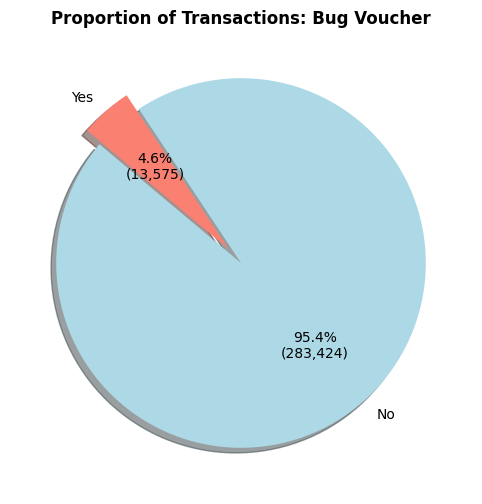

In [33]:
counts = df_merge_clean['voucher_bug'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(
    counts,
    labels=counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(counts)/100):,})',
    startangle=140,
    colors=['lightblue','salmon'],
    explode=(0, 0.1),
    shadow=True
)

plt.title('Proportion of Transactions: Bug Voucher', fontweight='bold')
plt.show()

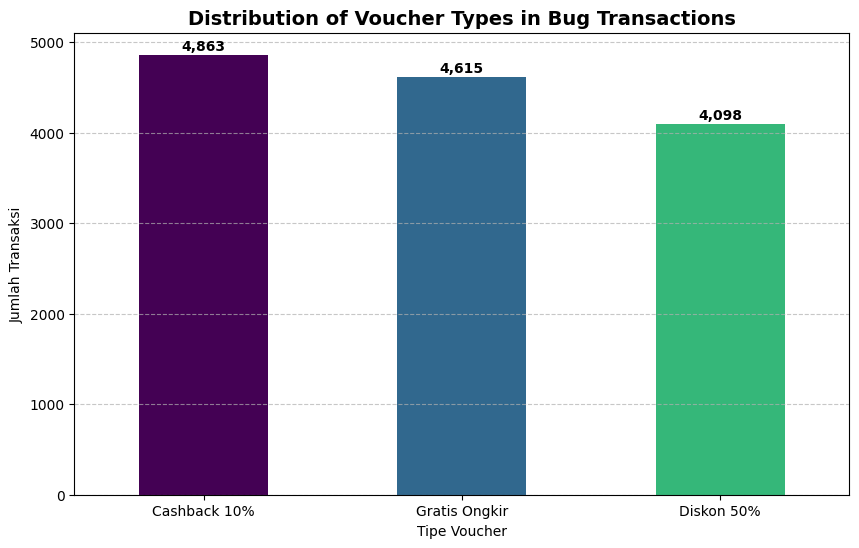

In [34]:
plt.figure(figsize=(10, 6))
bug_counts = df_merge_clean[df_merge_clean['voucher_bug'] == 'Yes']['voucher_type'].value_counts()

ax = bug_counts.plot(kind='bar', color=['#440154', '#31688e', '#35b779'])

for i, v in enumerate(bug_counts):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.title('Distribution of Voucher Types in Bug Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Tipe Voucher')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

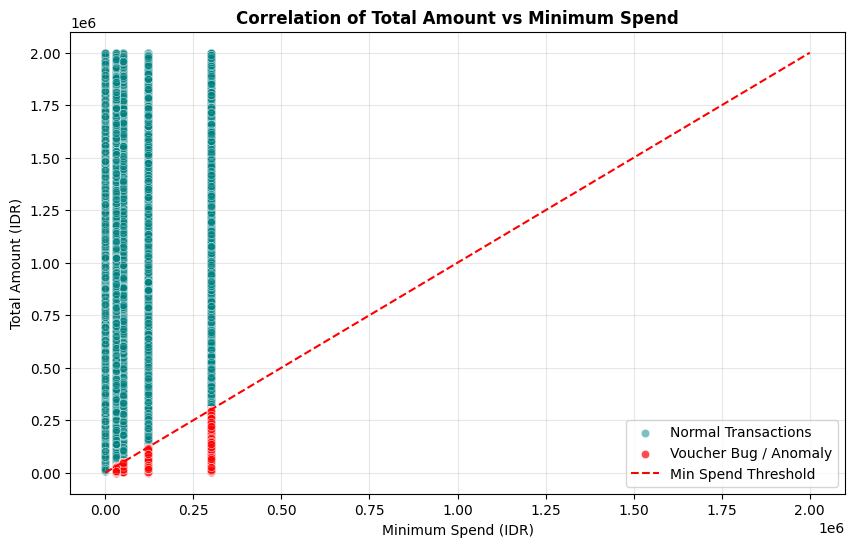

In [35]:
plt.figure(figsize=(10, 6))

df_normal = df_merge_clean[df_merge_clean['total_amount'] >= df_merge_clean['min_spend']]
df_anomaly = df_merge_clean[df_merge_clean['total_amount'] < df_merge_clean['min_spend']]

sns.scatterplot(data=df_normal, x='min_spend', y='total_amount', alpha=0.5, color='teal', label='Normal Transactions')
sns.scatterplot(data=df_anomaly, x='min_spend', y='total_amount', alpha=0.7, color='red', label='Voucher Bug / Anomaly')

lims = [0, df_merge_clean[['total_amount', 'min_spend']].max().max()]
plt.plot(lims, lims, 'r--', label='Min Spend Threshold')

plt.title('Correlation of Total Amount vs Minimum Spend', fontweight='bold')
plt.xlabel('Minimum Spend (IDR)')
plt.ylabel('Total Amount (IDR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
estimated_voucher_loss = df_merge_clean[df_merge_clean['voucher_bug'] == 'Yes']['discount_amount'].sum()

print(f"Estimasi kerugian dari kebocoran voucher: Rp {estimated_voucher_loss:,.2f}")

Estimasi kerugian dari kebocoran voucher: Rp 369,883,390.00


Terdapat 13576 transaksi yang mengalami *voucher bug* dengan estimasi kerugian sebesar Rp 369.883.390,00.

**Kesimpulan:** Jumlah transaksi dengan *voucher bug* dan kerugian finansial menunjukkan adanya celah serius dalam sistem validasi voucher. Perbaikan sistem ini sangat mendesak untuk mencegah kerugian berlanjut dan memastikan anggaran promosi digunakan secara efektif.

## **4. Bagaimana pola durasi checkout (dari masuk keranjang hingga bayar) yang mengindikasikan transaksi tersebut dilakukan oleh bot/script?**

In [37]:
# Uji Statistik Untuk Memastikan Normal/Tidak Data (Shapiro)
# Jika P-Value < 0.05 (5%) Data Tidak Berdistribusi Normal

stat, pval = sc.shapiro(df_merge_clean['checkout_duration_sec'])

if pval < 0.05 :
  print('Data Tidak Berdistribusi Normal')
else :
  print('Data Berdistribusi Normal')

Data Tidak Berdistribusi Normal


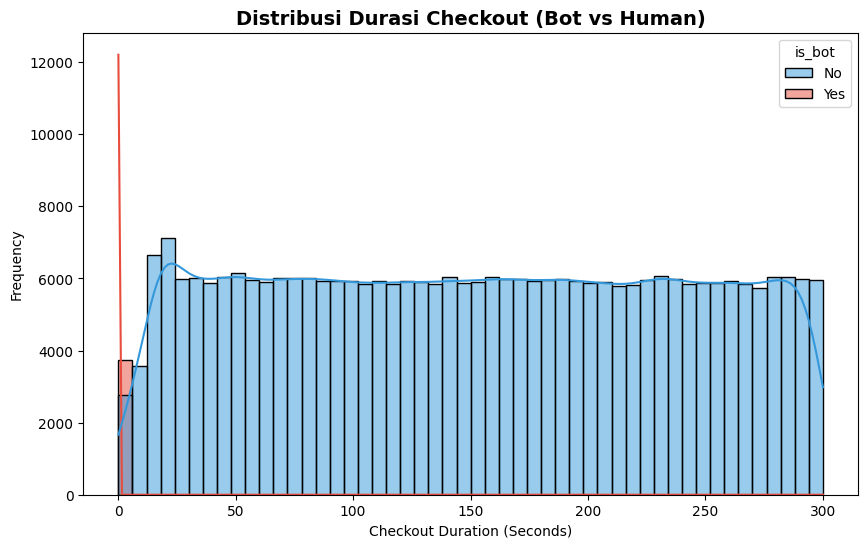

In [38]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_merge_clean, x='checkout_duration_sec', hue='is_bot', bins=50, kde=True, palette={'No': '#3498db', 'Yes': '#e74c3c'})
plt.title('Distribusi Durasi Checkout (Bot vs Human)', fontsize=14, fontweight='bold')
plt.xlabel('Checkout Duration (Seconds)')
plt.ylabel('Frequency')
plt.show()

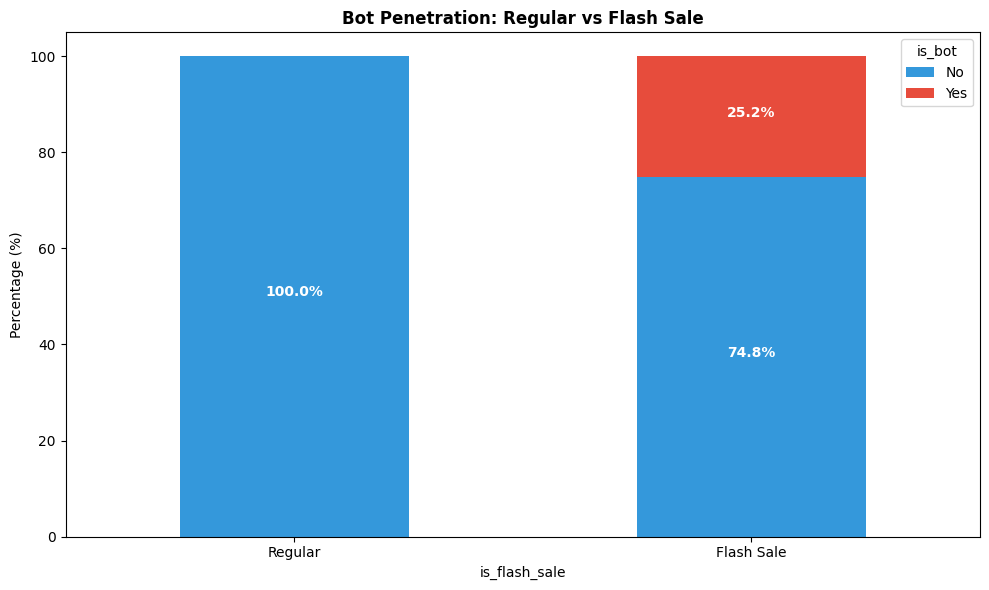

In [39]:
bot_fs_ratio = pd.crosstab(df_merge_clean['is_flash_sale'], df_merge_clean['is_bot'], normalize='index') * 100
ax = bot_fs_ratio.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], figsize=(10, 6))

plt.title('Bot Penetration: Regular vs Flash Sale', fontweight='bold')
plt.xticks([0, 1], ['Regular', 'Flash Sale'], rotation=0)
plt.ylabel('Percentage (%)')

# Simple label loop
for p in ax.patches:
    if p.get_height() > 0:
        ax.text(p.get_x() + p.get_width()/2, p.get_y() + p.get_height()/2, f'{p.get_height():.1f}%',
                ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

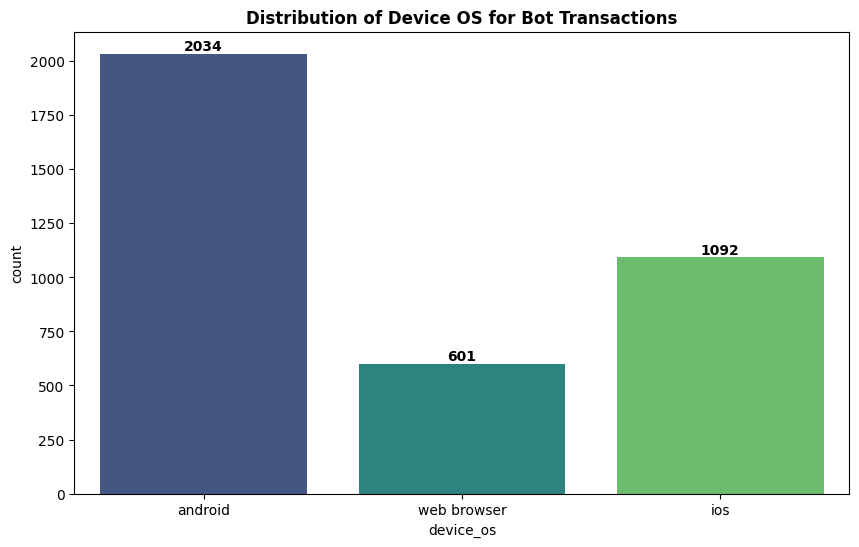

In [40]:
plt.figure(figsize=(10, 6))
bot_df = df_merge_clean[df_merge_clean['is_bot'] == 'Yes']
ax = sns.countplot(data=bot_df, x='device_os', palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom', fontweight='bold')

plt.title('Distribution of Device OS for Bot Transactions', fontweight='bold')
plt.show()

1. **Anomali Durasi Checkout** Bot melakukan checkout sangat cepat (<1 detik), tidak realistis untuk manusia. Sementara itu, transaksi manusia memiliki durasi normal (rata-rata 150 detik).

2. **Bot di Flash Sale**
Bot hanya muncul di Flash Sale dan mencapai 25,2% dari total transaksi, menunjukkan adanya penggunaan skrip otomatis untuk memanfaatkan diskon besar.

3. Perangkat Bot
Mayoritas bot menggunakan Android, disusul iOS, kemungkinan melalui emulator atau perangkat yang dimodifikasi.

Kesimpulan:
Bot secara signifikan mengganggu Flash Sale dengan mengambil porsi besar transaksi, menyebabkan kerugian finansial dan menurunkan kepercayaan pengguna.

## **5. Apakah ada korelasi antara metode pembayaran tertentu (misal: Transfer Bank Manual) dengan tingkat keberhasilan transaksi bot di Flash Sale?**

Analisis ini tidak dapat dilakukan karena tidak ditemukan dataset yang berisi informasi mengenai metode pembayaran.

Untuk analisis fraud yang lebih komprehensif di masa mendatang, sangat disarankan untuk menyertakan data metode pembayaran dalam dataset transaksi.

Informasi ini krusial untuk mengidentifikasi pola-pola fraud yang mungkin memanfaatkan metode pembayaran tertentu dan membantu dalam membangun strategi mitigasi yang lebih efektif.

## **6. Device ID mana saja yang terafiliasi dengan ratusan akun berbeda (indikasi farm account)?**

In [41]:
# Top 10 Devices with most unique users
farm_accounts = df_merge_clean.groupby('device_id')['user_id'].nunique().nlargest(10)

print("Top 10 Devices indicating Farm Accounts:")
print(farm_accounts)

Top 10 Devices indicating Farm Accounts:
device_id
Unknown      600
DEV-04178      9
DEV-04958      9
DEV-05833      9
DEV-08073      9
DEV-01806      8
DEV-02263      8
DEV-03833      8
DEV-04168      8
DEV-00605      7
Name: user_id, dtype: int64


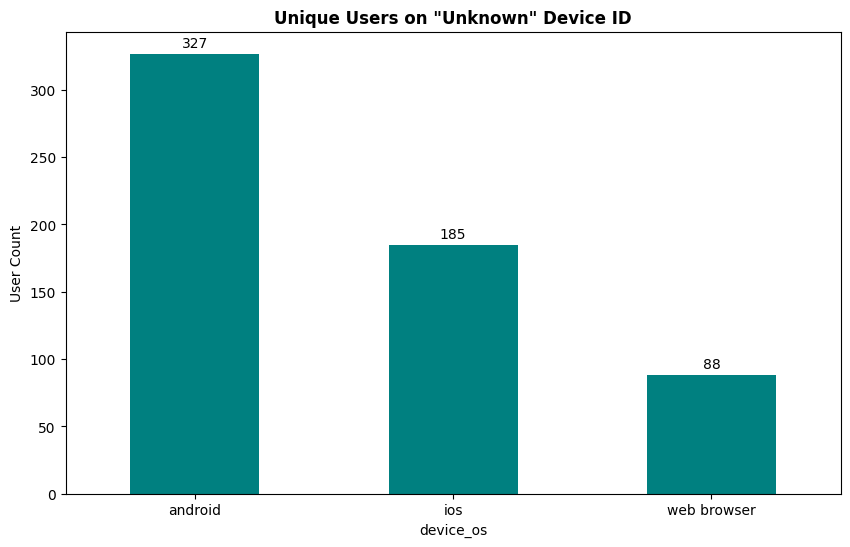

In [42]:
unknown_stats = df_merge_clean[df_merge_clean['device_id'] == 'Unknown'].groupby('device_os')['user_id'].nunique()

plt.figure(figsize=(10, 6))
ax = unknown_stats.plot(kind='bar', color='teal')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height() + 5), ha='center')

plt.title('Unique Users on "Unknown" Device ID', fontweight='bold')
plt.ylabel('User Count')
plt.xticks(rotation=0)
plt.show()

**Device ID 'Unknown':** Ini adalah temuan paling signifikan, di mana 600 *User ID* terkait dengan `device_id` yang 'Unknown'. Hal ini sangat mencurigakan karena ketiadaan identifikasi perangkat dapat mengindikasikan upaya penyembunyian identitas, penggunaan *emulator*, atau *script* otomatis.

Beberapa `device_id` seperti DEV-04178, DEV-05833, DEV-08073, dst. menunjukkan afiliasi dengan 7-9 akun berbeda. Dalam penggunaan normal, satu perangkat jarang digunakan oleh lebih dari 2-3 akun. Ini bisa saja menjadi ciri khas *farm account* yang digunakan untuk mendaftar banyak akun palsu dan mengeksploitasi promo.

# **KESIMPULAN DAN REKOMENDASI**

## **A. KESIMPULAN ANALISIS (Business Insights)**
---

Berikut adalah ringkasan kesimpulan dari hasil analisis:

**Standarisasi Device OS :**
* Pencatatan `device_os` awalnya sangat berantakan, namun
berhasil distandarisasi dari 9 kategori menjadi 3 kategori utama ('android', 'ios', 'web browser'). Hal ini krusial untuk deteksi *fraud* yang lebih akurat melalui pola penggunaan perangkat.

**Anomali Shopee Coin :**
* Ditemukan 6886 transaksi mencurigakan di mana pengguna menukarkan Shopee Coins melebihi saldo yang mereka miliki, mengindikasikan bug atau celah sistem. Kerugian finansial dari kebocoran ini sebesar Rp 2.553.584, menunjukkan perlunya perbaikan validasi koin.

**Kebocoran Voucher :**
* Terdapat 13576 transaksi dengan *voucher bug* (voucher digunakan tanpa memenuhi `min_spend`), dengan estimasi kerugian Rp 369.883.390,00. Ini menandakan celah serius dalam sistem validasi voucher yang mendesak untuk diperbaiki.

**Pola Bot pada Durasi Checkout :**
* Transaksi bot terakumulasi ekstrem di durasi checkout mendekati 0 detik, sementara transaksi manusia rata-rata di atas 100 detik. Sekitar 25% transaksi Flash Sale dikuasai bot, membuktikan bot dirancang khusus untuk mengeksploitasi promo dan mengurangi kesempatan pengguna asli.

**Korelasi Metode Pembayaran dengan Bot :**
* Analisis ini tidak dapat dilakukan karena tidak tersedianya data metode pembayaran dalam dataset. Untuk analisis *fraud* yang lebih komprehensif di masa mendatang, penyertaan data metode pembayaran sangat disarankan.

**Device ID dan Farm Account :**
* `Device_id` 'Unknown' terkait dengan 600 *User ID* berbeda, dan beberapa `device_id` spesifik terkait dengan 7-9 akun. Pola ini secara jelas mengindikasikan aktivitas *farm account* yang perlu segera ditangani melalui peningkatan deteksi perangkat dan kebijakan pembatasan akun.

## **B. REKOMENDASI STRATEGIS (Actionable Plan)**
---

Berdasarkan temuan analisis mendalam, berikut adalah rekomendasi strategis dan tindakan yang dapat diambil untuk mengatasi masalah fraud, meningkatkan integritas platform, dan mengoptimalkan anggaran promosi:

1. **Penerapan Multi-Factor Authentication (MFA) & CAPTCHA pada Flash Sale**
   - Mengingat **25.2%** transaksi Flash Sale dikuasai bot dengan durasi checkout < 1 detik, sistem harus mewajibkan tantangan CAPTCHA atau verifikasi biometrik sebelum tombol 'Bayar' aktif khusus untuk produk Flash Sale.

2. **Perbaikan Server-Side Validation untuk Promo**
   - **Voucher:** Segera tutup celah sistem yang mengizinkan diskon diaplikasikan tanpa mengecek `min_spend`. Implementasikan validasi `min_spend` yang kuat di sisi server untuk mencegah kebocoran anggaran promosi.

   - **Koin:** Implementasikan sinkronisasi saldo koin yang lebih ketat untuk mencegah penggunaan koin melebihi saldo (`coins_balance`).

3. **Kebijakan 'One Device, Two Accounts'**
   - Membatasi jumlah akun yang bisa login atau bertransaksi dalam satu `device_id` untuk menekan aktivitas *farm accounts*. Device dengan lebih dari 3 akun harus masuk ke dalam proses verifikasi manual atau *auto-flagging* oleh tim Fraud.

4. **Pengembangan Data Device**
   - Mengurangi proporsi `device_id` 'Unknown' dengan memperbarui SDK (Software Development Kit) pelacakan perangkat pada aplikasi mobile.

5. **Tambahan:**
    *   **Metode Pembayaran:** Sertakan data metode pembayaran dalam dataset transaksi di masa mendatang. Informasi ini krusial untuk menganalisis korelasi antara metode pembayaran tertentu dengan *fraud* (terutama bot di Flash Sale).

    * **Standarisasi Data Device OS:** Pertahankan standarisasi data `device_os` untuk analisis yang konsisten. Ini akan membantu tim Anti-Fraud dalam mengidentifikasi pola *fraud* berdasarkan jenis perangkat.